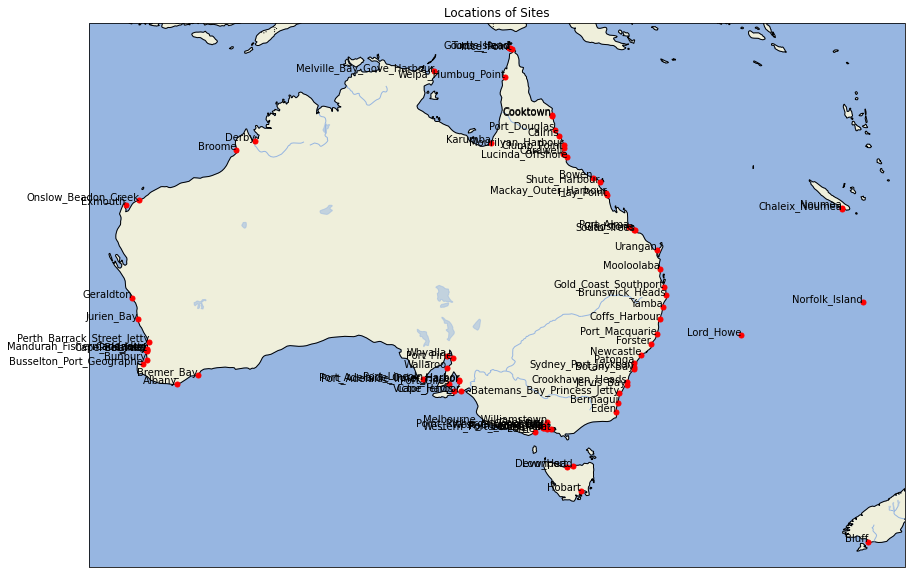

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the dataset
file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)

# Extract necessary variables
site_names = dataset['site_name'].values
latitudes = dataset['latitude'].values
longitudes = dataset['longitude'].values

# Create a map plot with Cartopy
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Plot the locations
for site, lat, lon in zip(site_names, latitudes, longitudes):
    ax.plot(lon, lat, marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
    ax.text(lon, lat, site, transform=ccrs.PlateCarree(), fontsize=10, ha='right')

# Set title and labels
ax.set_title('Locations of Sites')
plt.show()



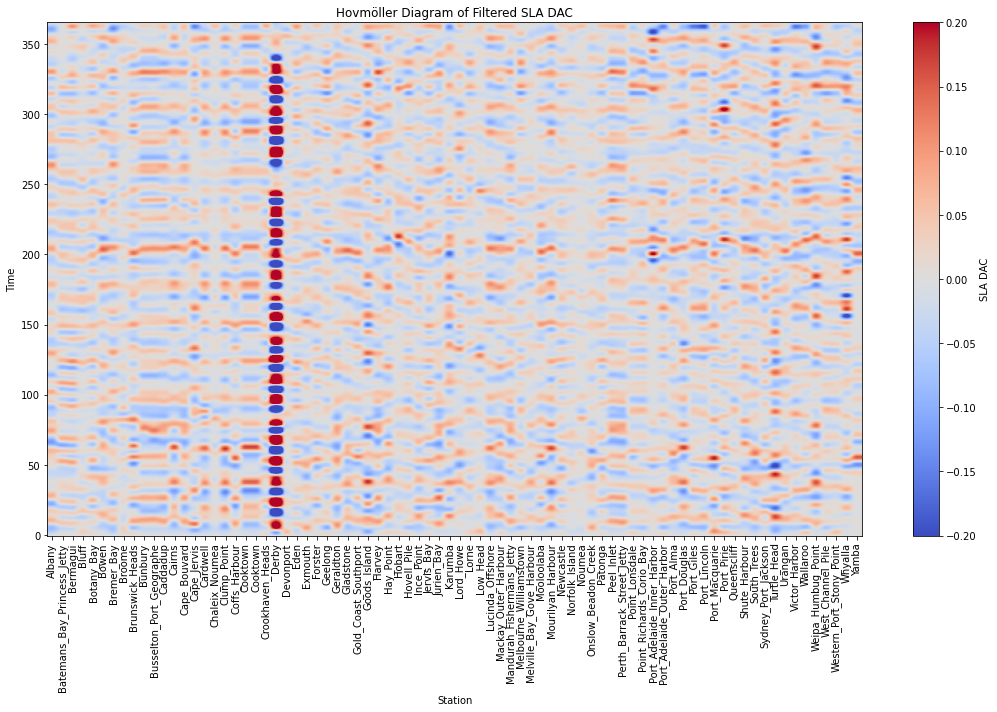

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import butter, filtfilt

# Load the dataset
file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)

# Convert hourly data to daily means
daily_dataset = dataset.resample(date_time='D').mean()

# Extract necessary variables
sla_dac = daily_dataset['sla_dac'].values
time = daily_dataset['date_time'].values
site_names = dataset['site_name'].values  # Keeping original site names, as they don't change with resampling

# Define the Butterworth bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def interpolate_nan(data):
    """Interpolate NaNs in the data."""
    nans, x = np.isnan(data), lambda z: z.nonzero()[0]
    data[nans] = np.interp(x(nans), x(~nans), data[~nans])
    return data

# Frequency cutoffs in cycles per day
lowcut = 0.035
highcut = 0.15
fs = 1.0  # Sampling frequency in cycles per day

# Apply the Butterworth bandpass filter to each time series
filtered_sla_dac = []
valid_site_names = []
for i in range(sla_dac.shape[1]):
    series = sla_dac[:, i]
    nan_count = np.isnan(series).sum()
    if nan_count <= 0.9 * len(time):  # Keep if less than or equal to 90% NaNs
        if nan_count > 0:
            series = interpolate_nan(series)
        series = butter_bandpass_filter(series, lowcut, highcut, fs, order=5)
        filtered_sla_dac.append(series)
        valid_site_names.append(site_names[i])

filtered_sla_dac = np.array(filtered_sla_dac)

# Create the Hovmöller diagram using imshow with masked array
fig, ax = plt.subplots(figsize=(15, 10))

# Set normalization for the color scale
norm = Normalize(vmin=-0.2, vmax=0.2)

# Plot using imshow with masked array
im = ax.imshow(filtered_sla_dac.T, aspect='auto', cmap='coolwarm', origin='lower', norm=norm)

# Set labels and title
ax.set_xlabel('Station')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Diagram of Filtered SLA DAC')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SLA DAC')

# Set x-axis ticks and labels
ax.set_xticks(np.arange(len(valid_site_names)))
ax.set_xticklabels(valid_site_names, rotation=90)

plt.tight_layout()
plt.show()


/home/passaro/anaconda3/envs/machine_learning_altimetry_validation/lib/python3.6/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Shape of filtered_sla_dac_filtered: (366, 14)
Number of valid site names: 14


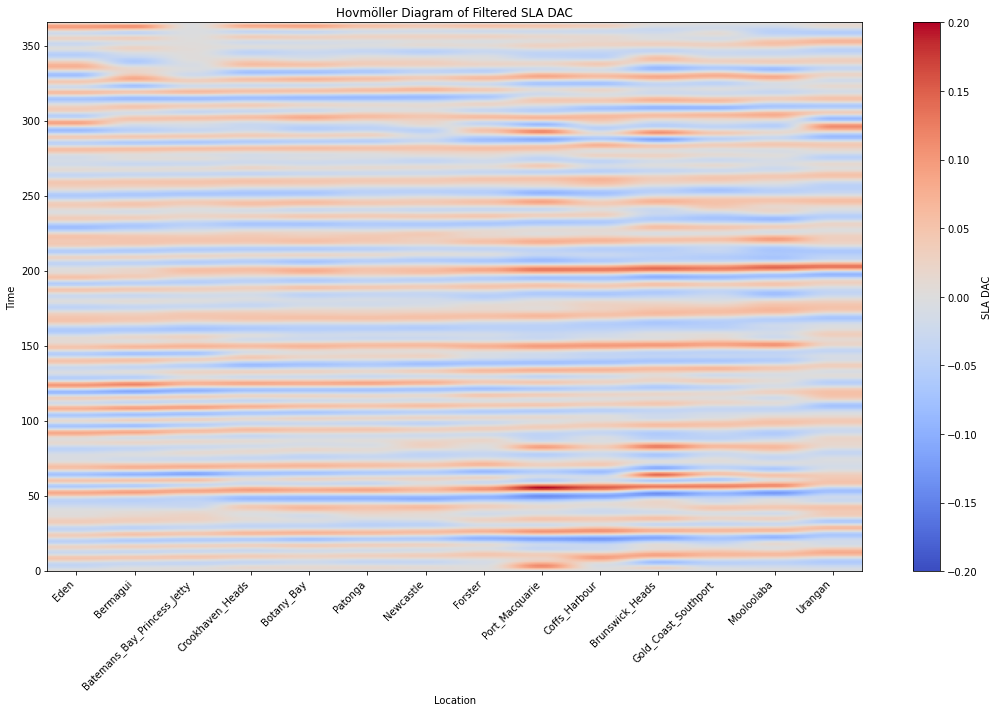

Latitude and Longitude for Selected Locations:
Eden: Latitude -37.0712, Longitude 149.9083
Bermagui: Latitude -36.42633887, Longitude 150.0715333
Batemans_Bay_Princess_Jetty: Latitude -35.7049, Longitude 150.1779
Crookhaven_Heads: Latitude -34.9066, Longitude 150.7592
Botany_Bay: Latitude -33.9684, Longitude 151.2204
Patonga: Latitude -33.55098053, Longitude 151.27462
Newcastle: Latitude -32.9238, Longitude 151.7889
Forster: Latitude -32.17398888, Longitude 152.5082112
Port_Macquarie: Latitude -31.42679171, Longitude 152.9109833
Coffs_Harbour: Latitude -30.30285837, Longitude 153.1460611
Brunswick_Heads: Latitude -28.53681115, Longitude 153.55211
Gold_Coast_Southport: Latitude -27.9667, Longitude 153.4167
Mooloolaba: Latitude -26.6867, Longitude 153.12
Urangan: Latitude -25.2983, Longitude 152.9083


In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import butter, filtfilt
from fuzzywuzzy import process

# Load the dataset
file_path = 'gesla_2004_selected_lowess_dac_correctedaustralia_2004.nc'
dataset = xr.open_dataset(file_path)

# Convert hourly data to daily means
daily_dataset = dataset.resample(date_time='D').mean()

# Extract necessary variables
sla_dac = daily_dataset['sla_dac'].values
time = daily_dataset['date_time'].values
site_names = dataset['site_name'].values
latitudes = dataset['latitude'].values
longitudes = dataset['longitude'].values

# Define the Butterworth bandpass filter
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def interpolate_nan(data):
    """Interpolate NaNs in the data."""
    nans, x = np.isnan(data), lambda z: z.nonzero()[0]
    data[nans] = np.interp(x(nans), x(~nans), data[~nans])
    return data

# Frequency cutoffs in cycles per day
lowcut = 0.035
highcut = 0.15
fs = 1.0  # Sampling frequency in cycles per day

# List of selected locations to keep in the plot
selected_locations = [
    'Eden','Bernagui','Jetty', 'Crookhaven_Heads','Botany_Bay','Patonga','Newcastle','Forster','Port_Macquarie','Coffs_Harbour','Brunswick_Heads','Gold_Coast_Southport','Mooloolaba','Urangan'
]

# Find closest matches for selected locations in the dataset's site_names
filtered_indices = []
valid_site_names = []
valid_latitudes = []
valid_longitudes = []

for loc in selected_locations:
    match = process.extractOne(loc, site_names)
    if match[1] >= 80:  # Minimum similarity score threshold
        idx = np.where(site_names == match[0])[0][0]
        filtered_indices.append(idx)
        valid_site_names.append(match[0])
        valid_latitudes.append(latitudes[idx])
        valid_longitudes.append(longitudes[idx])
    else:
        print(f"No close match found for '{loc}'.")

# Filter sla_dac and reorder according to filtered indices
filtered_sla_dac = sla_dac[:, filtered_indices]

# Apply the Butterworth bandpass filter to each time series
filtered_sla_dac_filtered = []
for i in range(filtered_sla_dac.shape[1]):
    series = filtered_sla_dac[:, i]
    nan_count = np.isnan(series).sum()
    if nan_count <= 0.9 * len(time):  # Keep if less than or equal to 90% NaNs
        if nan_count > 0:
            series = interpolate_nan(series)
        series = butter_bandpass_filter(series, lowcut, highcut, fs, order=5)
        filtered_sla_dac_filtered.append(series)

filtered_sla_dac_filtered = np.array(filtered_sla_dac_filtered).T  # Transpose for correct shape

# Check the shapes of the data arrays
print("Shape of filtered_sla_dac_filtered:", filtered_sla_dac_filtered.shape)
print("Number of valid site names:", len(valid_site_names))

# Create the Hovmöller diagram using imshow with masked array
fig, ax = plt.subplots(figsize=(15, 10))

# Set normalization for the color scale
norm = Normalize(vmin=-0.2, vmax=0.2)

# Plot using imshow with masked array
im = ax.imshow(filtered_sla_dac_filtered, aspect='auto', cmap='coolwarm', origin='lower', norm=norm)

# Set labels and title
ax.set_xlabel('Location')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Diagram of Filtered SLA DAC')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SLA DAC')

# Set x-axis ticks and labels (locations)
ax.set_xticks(np.arange(len(valid_site_names)))
ax.set_xticklabels(valid_site_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Print latitude and longitude for each selected location
print("Latitude and Longitude for Selected Locations:")
for name, lat, lon in zip(valid_site_names, valid_latitudes, valid_longitudes):
    print(f"{name}: Latitude {lat}, Longitude {lon}")


Open with xarray an example file of the dataset located in /DGFI8/H/work_marcello/giussani_machinelearning_data/SEALEVEL_GLO_PHY_L4_REP_OBSERVATIONS_008_047/2004, which is divided in subfolders from 01 to 12 corresponding to the months, and each subfolder contain daily gridded sea level data in files like this one: dt_global_allsat_phy_l4_20040211_20210726.nc


Dataset Information:
<xarray.Dataset>
Dimensions:         (latitude: 720, longitude: 1440, nv: 2, time: 1)
Coordinates:
  * time            (time) datetime64[ns] 2004-01-26
  * latitude        (latitude) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * longitude       (longitude) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
  * nv              (nv) int32 0 1
Data variables: (12/14)
    crs             int32 ...
    lat_bnds        (latitude, nv) float32 ...
    lon_bnds        (longitude, nv) float32 ...
    sla             (time, latitude, longitude) float64 ...
    err_sla         (time, latitude, longitude) float64 ...
    ugosa           (time, latitude, longitude) float64 ...
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 ...
    adt             (time, latitude, longitude) float64 ...
    ugos            (time, latitude, longitude) float64 ...
    vgos            (time, latitude, longitude) float64 ...
    flag_ice        (time, latitude, longitude) float64 ...
    tpa_correction  (time) float64 ...
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               2004-01-26T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2004-01-25T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...



I will give you now the structure of each file

Extract from a random latitude longitude point a complete time series of the variable "sla"

In [4]:
import os
import xarray as xr
import pandas as pd
import numpy as np

# Define the base directory where the dataset files are located
base_dir = '/DGFI8/H/work_marcello/giussani_machinelearning_data/SEALEVEL_GLO_PHY_L4_REP_OBSERVATIONS_008_047/2004'

# Define locations of interest with latitude and longitude
locations = {
    'Eden': (-37.0712, 149.9083),
    'Bermagui': (-36.42633887, 150.0715333),
    'Batemans_Bay_Princess_Jetty': (-35.7049, 150.1779),
    'Crookhaven_Heads': (-34.9066, 150.7592),
    'Botany_Bay': (-33.9684, 151.2204),
    'Patonga': (-33.55098053, 151.27462),
    'Newcastle': (-32.9238, 151.7889),
    'Forster': (-32.17398888, 152.5082112),
    'Port_Macquarie': (-31.42679171, 152.9109833),
    'Coffs_Harbour': (-30.30285837, 153.1460611),
    'Brunswick_Heads': (-28.53681115, 153.55211),
    'Gold_Coast_Southport': (-27.9667, 153.4167),
    'Mooloolaba': (-26.6867, 153.12),
    'Urangan': (-25.2983, 152.9083)
}

# Initialize an empty dictionary to store time series data for each location
sla_time_series = {loc: [] for loc in locations}

# Iterate through each month directory (01 to 12)
for month in range(1, 13):
    month_str = f"{month:02d}"  # Format month as two digits
    
    # Iterate through each day file in the month directory
    for file_name in os.listdir(os.path.join(base_dir, month_str)):
        if file_name.endswith('.nc'):
            file_path = os.path.join(base_dir, month_str, file_name)
            
            # Open the dataset for the current file
            dataset = xr.open_dataset(file_path)
            
            # Iterate through each location of interest
            for loc, (lat, lon) in locations.items():
                # Find nearest indices to the specified latitude and longitude
                lat_idx = abs(dataset.latitude - lat).argmin()
                lon_idx = abs(dataset.longitude - lon).argmin()
                
                # Check if the point contains valid data (not NaN)
                if not np.isnan(dataset['sla'].isel(latitude=lat_idx, longitude=lon_idx).values):
                    # Extract sla at the specified point for the current file
                    sla_data_point = dataset['sla'].isel(latitude=lat_idx, longitude=lon_idx).values.item()
                    
                    # Append sla data point to the time series list for the current location
                    sla_time_series[loc].append(sla_data_point)
            
            # Close the dataset
            dataset.close()

# Convert the lists to xarray DataArray with time dimension
time_index = pd.date_range(start='2004-01-01', end='2004-12-31', freq='D')
sla_time_series_da = {loc: xr.DataArray(sla_ts, dims=['time'], coords={'time': time_index}) for loc, sla_ts in sla_time_series.items()}




I will show you now the dataset information. From this dataset, you have to create one similar to the one contained in filtered_sla_dac_filtered, so that for each location identified in filtered_sla_dac_filtered you find the closest point in this new dataset extracting the field "sla"

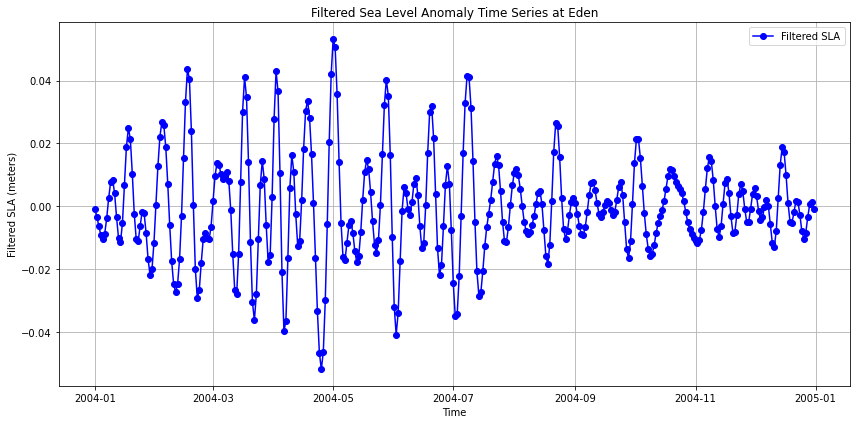

In [5]:
import numpy as np
from scipy.signal import butter, filtfilt
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt



# Load the dataset for 2004
base_dir = '/DGFI8/H/work_marcello/giussani_machinelearning_data/SEALEVEL_GLO_PHY_L4_REP_OBSERVATIONS_008_047/2004'

# Define locations and their coordinates
locations = {
    'Eden': {'latitude': -37.0712, 'longitude': 149.9083},
    'Bermagui': {'latitude': -36.42633887, 'longitude': 150.0715333},
    'Batemans_Bay_Princess_Jetty': {'latitude': -35.7049, 'longitude': 150.1779},
    'Crookhaven_Heads': {'latitude': -34.9066, 'longitude': 150.7592},
    'Botany_Bay': {'latitude': -33.9684, 'longitude': 151.2204},
    'Patonga': {'latitude': -33.55098053, 'longitude': 151.27462},
    'Newcastle': {'latitude': -32.9238, 'longitude': 151.7889},
    'Forster': {'latitude': -32.17398888, 'longitude': 152.5082112},
    'Port_Macquarie': {'latitude': -31.42679171, 'longitude': 152.9109833},
    'Coffs_Harbour': {'latitude': -30.30285837, 'longitude': 153.1460611},
    'Brunswick_Heads': {'latitude': -28.53681115, 'longitude': 153.55211},
    'Gold_Coast_Southport': {'latitude': -27.9667, 'longitude': 153.4167},
    'Mooloolaba': {'latitude': -26.6867, 'longitude': 153.12},
    'Urangan': {'latitude': -25.2983, 'longitude': 152.9083},
}

# Initialize a dictionary to store filtered time series
filtered_sla_time_series = {}

# Iterate through each location
for location, coords in locations.items():
    latitude = coords['latitude']
    longitude = coords['longitude']
    
    # Initialize an empty list to store sla data for the location
    sla_data = []
    
    # Iterate through each month directory (01 to 12)
    for month in range(1, 13):
        month_str = f"{month:02d}"  # Format month as two digits
        
        # Iterate through each day file in the month directory
        for file_name in os.listdir(os.path.join(base_dir, month_str)):
            if file_name.endswith('.nc'):
                file_path = os.path.join(base_dir, month_str, file_name)
                
                # Open the dataset for the current file
                dataset = xr.open_dataset(file_path)
                
                # Find nearest indices to the specified latitude and longitude
                lat_idx = abs(dataset.latitude - latitude).argmin()
                lon_idx = abs(dataset.longitude - longitude).argmin()
                
                # Extract sla at the specified point for the current file
                sla_data_point = dataset['sla'].isel(latitude=lat_idx, longitude=lon_idx).values.item()
                
                # Append sla data point to the list
                sla_data.append(sla_data_point)
                
                # Close the dataset
                dataset.close()
    
    # Convert the list to xarray DataArray with time dimension
    time_index = pd.date_range(start='2004-01-01', end='2004-12-31', freq='D')
    sla_time_series_da = xr.DataArray(sla_data, dims=['time'], coords={'time': time_index})
    
    # Apply the Butterworth bandpass filter to the time series
    series = sla_time_series_da.values
    nan_count = np.isnan(series).sum()  # Count NaNs
    
    # Apply filtering only if less than or equal to 90% NaNs
    if nan_count <= 0.9 * len(sla_time_series_da.time):
        if nan_count > 0:
            series = interpolate_nan(series)  # Interpolate NaNs
        filtered_series = butter_bandpass_filter(series, lowcut, highcut, fs, order=5)  # Apply filter
    else:
        print(f"Skipping location '{location}' due to excessive NaNs.")
        filtered_series = np.full_like(series, np.nan)  # Create NaN-filled array
    
    # Store filtered series in dictionary
    filtered_sla_time_series[location] = filtered_series

# Example plot of one location's filtered time series (e.g., 'Eden')
location = 'Eden'
plt.figure(figsize=(12, 6))
plt.plot(time_index, filtered_sla_time_series[location], marker='o', linestyle='-', color='b', label='Filtered SLA')
plt.title(f'Filtered Sea Level Anomaly Time Series at {location}')
plt.xlabel('Time')
plt.ylabel('Filtered SLA (meters)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


sla_time_series_da is an xarray DataArray containing sea level anomaly (SLA) time series data from tide gauges.
filtered_sla_time_series is a dictionary containing filtered sea level anomaly (SLA) time series data for the same locations from cmems. Please join the two in one single xarray DataArray

Shape of filtered_sla_array: (366, 14)


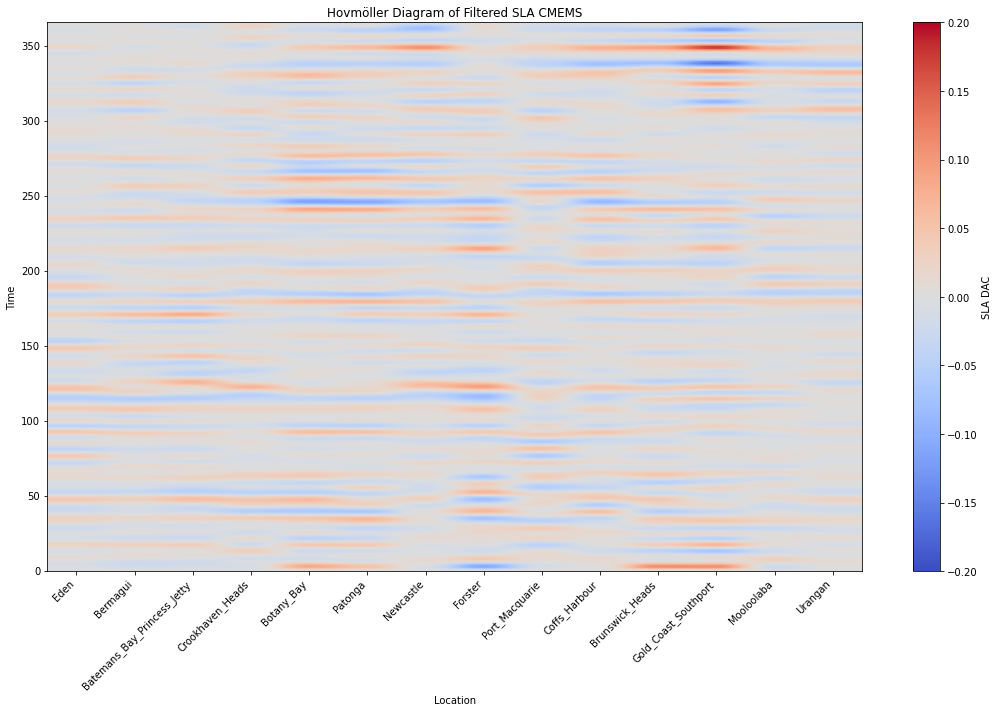

Latitude and Longitude for Selected Locations:
Eden: Latitude -37.0712, Longitude 149.9083
Bermagui: Latitude -36.42633887, Longitude 150.0715333
Batemans_Bay_Princess_Jetty: Latitude -35.7049, Longitude 150.1779
Crookhaven_Heads: Latitude -34.9066, Longitude 150.7592
Botany_Bay: Latitude -33.9684, Longitude 151.2204
Patonga: Latitude -33.55098053, Longitude 151.27462
Newcastle: Latitude -32.9238, Longitude 151.7889
Forster: Latitude -32.17398888, Longitude 152.5082112
Port_Macquarie: Latitude -31.42679171, Longitude 152.9109833
Coffs_Harbour: Latitude -30.30285837, Longitude 153.1460611
Brunswick_Heads: Latitude -28.53681115, Longitude 153.55211
Gold_Coast_Southport: Latitude -27.9667, Longitude 153.4167
Mooloolaba: Latitude -26.6867, Longitude 153.12
Urangan: Latitude -25.2983, Longitude 152.9083


In [23]:
import numpy as np
import xarray as xr

# Assuming filtered_sla_time_series is already defined as a dictionary

# Extract time series and convert to numpy arrays
time_series_arrays = []
for location in filtered_sla_time_series:
    time_series = filtered_sla_time_series[location]
    time_series_arrays.append(time_series)

# Stack arrays along a new axis (assuming each time series has daily values for 2004)
filtered_sla_array_cmems = np.stack(time_series_arrays, axis=1)

# Verify the shape of the resulting array
print("Shape of filtered_sla_array:", filtered_sla_array_cmems.shape)
# Expected output: (366, 14)

# Create the Hovmöller diagram using imshow with masked array
fig, ax = plt.subplots(figsize=(15, 10))

# Set normalization for the color scale
norm = Normalize(vmin=-0.2, vmax=0.2)

# Plot using imshow with masked array
im = ax.imshow(filtered_sla_array_cmems, aspect='auto', cmap='coolwarm', origin='lower', norm=norm)

# Set labels and title
ax.set_xlabel('Location')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Diagram of Filtered SLA CMEMS')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SLA DAC')

# Set x-axis ticks and labels (locations)
ax.set_xticks(np.arange(len(valid_site_names)))
ax.set_xticklabels(valid_site_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Print latitude and longitude for each selected location
print("Latitude and Longitude for Selected Locations:")
for name, lat, lon in zip(valid_site_names, valid_latitudes, valid_longitudes):
    print(f"{name}: Latitude {lat}, Longitude {lon}")


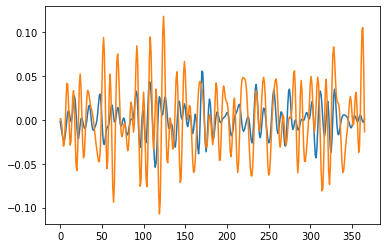

In [20]:
plt.plot(filtered_sla_array_cmems[:,1])
plt.plot(filtered_sla_dac_filtered[:,1])